# Set Atomic unit system

In [1]:
import atomic_units as au

hb=1.0
m0=8.8
kappa0=2.3 # 4*pi*epsilon0
e0=3.4
dx=0.045

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))

0.007297352569307101 dimensionless
0.12240749165941847 electron_volt
2.340527796123471 nanometer
0.10532375082555619 nanometer


# Set unified grid

### Spatial grid

In [2]:
import numpy as np

uxgrid_num = 16*1024
#uxgrid_dx = dx
uxgrid_width=uxgrid_num*dx
#uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)
uxgrid,uxgrid_dx = np.linspace(-uxgrid_width/2, uxgrid_width/2, uxgrid_num, retstep=True)
print(uxgrid_num, uxgrid_dx, uxgrid_width)

print(type(uxgrid)) 
print(uxgrid.min(), uxgrid.max(), uxgrid[1]-uxgrid[0],uxgrid.size,dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

16384 0.045002746749679544 737.28
<class 'numpy.ndarray'>
-368.64 368.64 0.04500274674967386 16384 0.045
737.28
1725.6243335259126 nanometer


### Spatial mask

In [3]:
uxgrid_num = len(uxgrid)
desired_points = 2048
step_size = max(1, uxgrid_num // max(1, desired_points))
mask_arr = np.zeros(uxgrid_num, dtype=bool)
mask_arr[::step_size] = True

### Temporal grid

In [4]:
t_start=0
t_stop=50.0
t_num=20000

utgrid, utgrid_dt=np.linspace(t_start,t_stop,t_num, retstep=True)
#utgrid_dt=utgrid[1]-utgrid[0]
# utgrid_dt=0.05
# utgrid=np.arange(t_start,t_stop,utgrid_dt)
# t_num=len(utgrid)

print(uxgrid_dx**2)
print(utgrid_dt)
#print(t_num)

0.002025247215015793
0.0025001250062503125


In [5]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.CosineDispersion(uxgrid_dx, hbar = unit_sys.hb, mass = unit_sys.me)

# Set model-potential

8.169434619102878
0.0
0.12240749165941847
1.2817621755950894
4.272540585316965


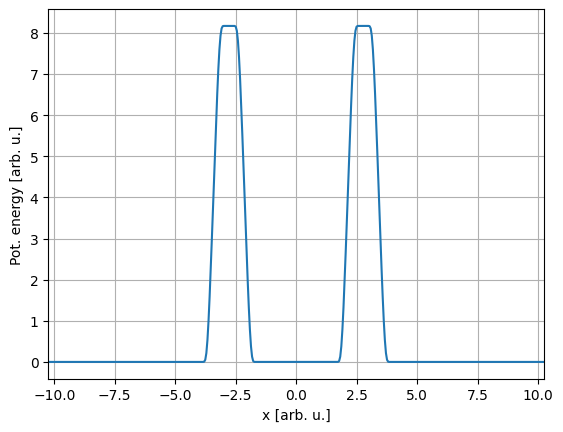

In [6]:
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import pint


wall_in_unit_sys = 1.0 * unit_sys.convert_energy_from('eV')
print(wall_in_unit_sys)


well_in_unit_sys = 0.0 * unit_sys.convert_energy_from('eV')
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = 3 * unit_sys.convert_length_from('nm')
print(wall_width)
well_width = 10 * unit_sys.convert_length_from('nm')
print(well_width)

cell_width_au = 2* wall_width + well_width 
cell_width_nm = cell_width_au * length_unit_in_nm

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 1,\
                                   wellfall = 1)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-1.5*cell_width_au, 1.5*cell_width_au])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


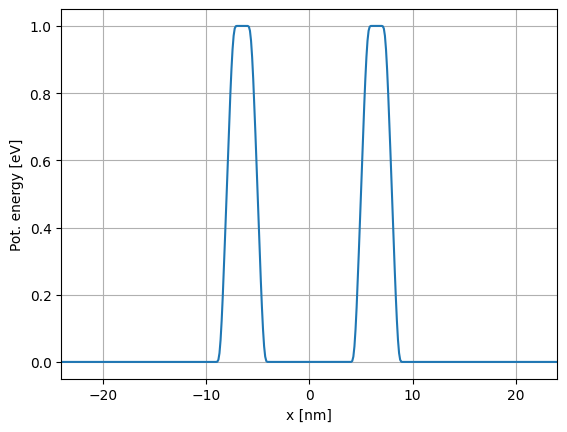

In [7]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
plt.xlim([-1.5*cell_width_nm, 1.5*cell_width_nm])
plt.grid()
plt.show()

In [8]:
zeropot=pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [9]:
t_vals=[]
r_vals=[]

energy_min = 0.9
energy_max = 1.4
number_of_points_in_energy = 11

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.wavenumber(energy_min_in_unit_sys)
k_max = dispersion.wavenumber(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,number_of_points_in_energy)

print(k_min,k_max,k_vals)

e_vals=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.energy(k)
    e_vals.append(ein)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    t_vals.append(qp_pk.transmission)
    r_vals.append(qp_pk.reflection)

    print(kin)

    num=len(t_vals)

    # plt.plot(k_vals[:num],t_vals,"-o",label="T")
    # plt.plot(k_vals[:num],r_vals,"-o",label="R")
    # plt.xlabel("k [arb. u.]")
    # #plt.ylabel("Coefficient")
    # plt.legend()
    # plt.grid()
    # plt.show()

11.50361184414267 14.440615446390906 [11.50361184 11.7973122  12.09101256 12.38471292 12.67841329 12.97211365
 13.26581401 13.55951437 13.85321473 14.14691509 14.44061545]
11.50361184414267
11.797312204367493
12.091012564592317
12.38471292481714
12.678413285041964
12.972113645266788
13.265814005491611
13.559514365716435
13.853214725941259
14.146915086166082
14.440615446390906


In [10]:
import h5py

output_file = "quasiparticles.h5"
with h5py.File(output_file, "w") as hdf:
    grp_particles = hdf.create_group("particles")
    for i, (qp_pk, qp_mk) in enumerate(zip(quasiparticles_pk, quasiparticles_mk)):
        grp_index = grp_particles.create_group(f"{i}.")
        grp_index.attrs["energy"] = qp_pk.angular_frequency * unit_sys.hb

        # Save particle with positive k using QuasiParticle method
        pk_grp = grp_index.create_group("positive_k")
        qp_pk.to_hdf5_group(pk_grp)

        # Save particle with negative k using QuasiParticle method
        mk_grp = grp_index.create_group("negative_k")
        qp_mk.to_hdf5_group(mk_grp)
        
print(f"Saved to {output_file}")

Saved to quasiparticles.h5


In [9]:
def load_quasiparticles_from_hdf5(filename):
    quasiparticles_pk = []
    quasiparticles_mk = []
    e_vals = []
    k_vals = []
    t_vals=[]
    r_vals=[]
    import h5py
    from quantum_toolkit.quantum_transport_toolkit import QuasiParticle
    with h5py.File(filename, "r") as hdf:
        particles_group = hdf["particles"]
        # --- csoportnevek rendezése numerikusan ---
        group_names = sorted(particles_group.keys(), key=lambda x: int(x.rstrip('.')))
        for group_name in group_names:
            group = particles_group[group_name]
            e_vals.append(group.attrs["energy"])
            print(f"Processing group: {group_name}, energy: {group.attrs['energy']}")
            # Positive k
            pk = QuasiParticle.from_hdf5_group(group["positive_k"])
            # Negative k
            mk = QuasiParticle.from_hdf5_group(group["negative_k"])
            k_vals.append(pk.wavenumber)
            t_vals.append(pk.transmission)
            r_vals.append(pk.reflection)
            quasiparticles_pk.append(pk)
            quasiparticles_mk.append(mk)
    return e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk

# Példa használat:
e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk = load_quasiparticles_from_hdf5("quasiparticles.h5")

Processing group: 0., energy: 7.352491157192588
Processing group: 1., energy: 7.72375168129821
Processing group: 2., energy: 8.103465022812046
Processing group: 3., energy: 8.491564847680658
Processing group: 4., energy: 8.887983356773248
Processing group: 5., energy: 9.292651297725774
Processing group: 6., energy: 9.705497977039014
Processing group: 7., energy: 10.126451272428385
Processing group: 8., energy: 10.555437645423346
Processing group: 9., energy: 10.992382154214194
Processing group: 10., energy: 11.437208466744028


In [10]:
print(e_vals)

[7.352491157192588, 7.72375168129821, 8.103465022812046, 8.491564847680658, 8.887983356773248, 9.292651297725774, 9.705497977039014, 10.126451272428385, 10.555437645423346, 10.992382154214194, 11.437208466744028]


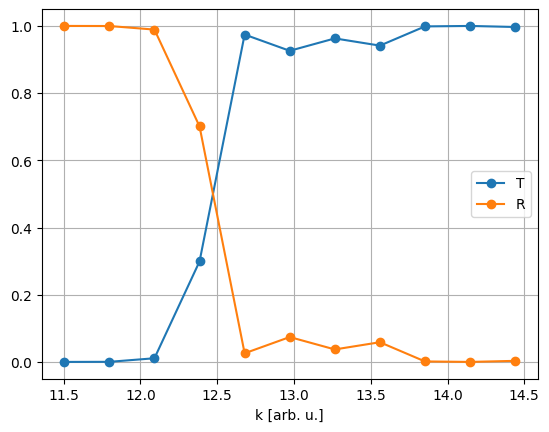

In [11]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

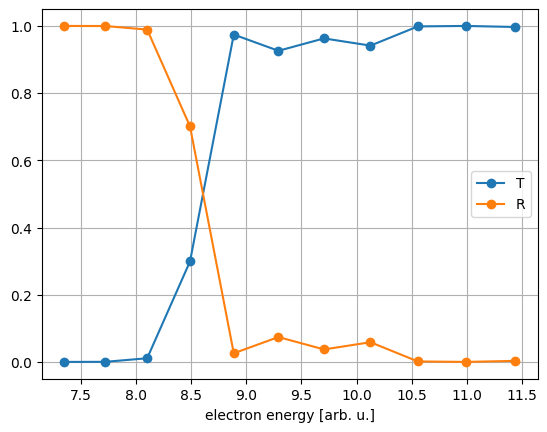

In [12]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [13]:
spot_size_nm = 800 # in nm
magnitude_of_electric_field_vm = 1.0 # in GV/m
central_wavelength_nm = 800 # in nm

In [14]:
central_wavelength = central_wavelength_nm*unit_sys.convert_length_from("nm")
print(central_wavelength)

omega = 2*np.pi*unit_sys.speed_of_light/central_wavelength_nm
print(omega)
num_of_cycles = 5 # one cycle is around 2.66 fs

t_min = 0
t_max = num_of_cycles*2*np.pi/omega
print("pulse length hus:",t_max,t_max*unit_sys.time_unit.to("fs"))

s_min = -0.5*spot_size_nm*unit_sys.convert_length_from("nm")
s_max = 0.5*spot_size_nm*unit_sys.convert_length_from("nm")
print("spot size:",s_min,s_max)


magnitude = magnitude_of_electric_field_vm*unit_sys.convert_electric_field_from("GV/m")
print(magnitude)

beta=0.2

laserpot = pots.SmoothLaserPotential(uxgrid, spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

laserpot_masked = pots.SmoothLaserPotential(uxgrid[mask_arr], spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

print(laserpot.omega0)

341.8032468253572
5.409467923108539
pulse length hus: 5.807581629552364 31.228641464002013 femtosecond
spot size: -170.9016234126786 170.9016234126786
5.623761413124601
5.409467923108539


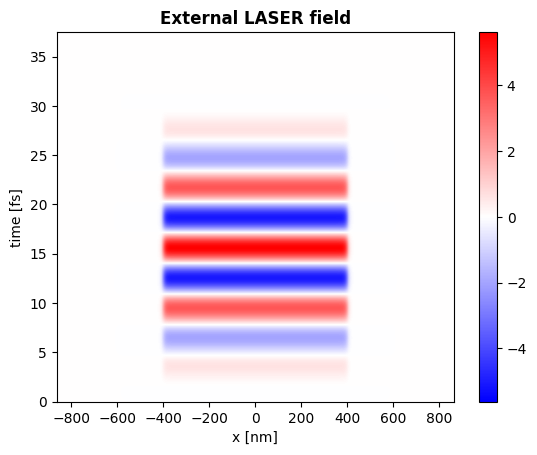

In [15]:
X,Y = np.meshgrid(uxgrid[mask_arr],utgrid)
X_nm,Y_fs = np.meshgrid(uxgrid[mask_arr]*unit_sys.length_unit.to('nm').magnitude,\
                  utgrid*unit_sys.time_unit.to('fs').magnitude)

Z=laserpot_masked(Y)

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X_nm, Y_fs, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('External LASER field', fontweight ="bold")
plt.ylim(0.0,1.2*laserpot_masked.temporal_max*unit_sys.time_unit.to('fs').magnitude)
#plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
plt.xlabel("x [nm]")
plt.ylabel("time [fs]")
plt.show()

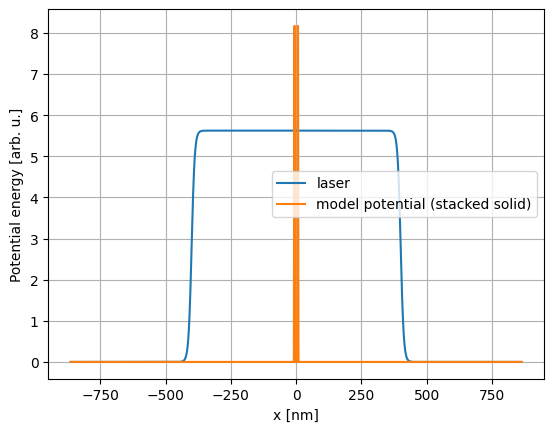

In [16]:
plt.plot(uxgrid[mask_arr]*unit_sys.length_unit.to("nm"),\
          laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          modelpot(uxgrid[mask_arr]),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

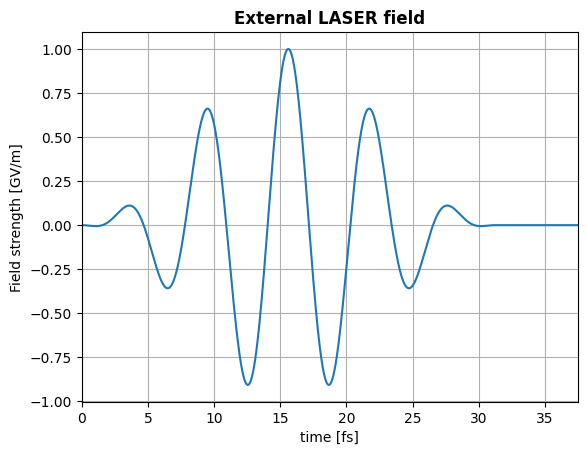

In [17]:
plt.plot(utgrid*unit_sys.time_unit.to('fs').magnitude,\
          laserpot.value_at(0.0,utgrid)*unit_sys.electric_field_unit.to('GV/m'),\
          label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [GV/m]")
plt.title('External LASER field', fontweight ="bold")
plt.xlim(0,1.2*laserpot.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

# Vcap check

## Advanced methode

In [18]:
from quantum_toolkit import quantum_transport_toolkit as trat

qp_index = 4

qppk, qpmk = quasiparticles_pk[qp_index], quasiparticles_mk[qp_index]

ein=qppk.angular_frequency * unit_sys.hb
kin=qppk.wavenumber

print(ein,ein*unit_sys.energy_unit.to('eV'))
print(kin,kin*unit_sys.wavenumber_unit.to('1/nm'))

8.887983356773248 1.0879557486132716 electron_volt
12.678413285041964 5.416903531776358 / nanometer


In [19]:
v_cap=quat.vcap_generator(uxgrid,param_x0=290,param_lambda0 = 0.07)

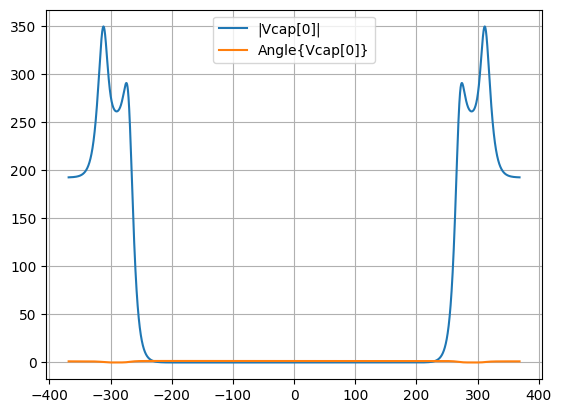

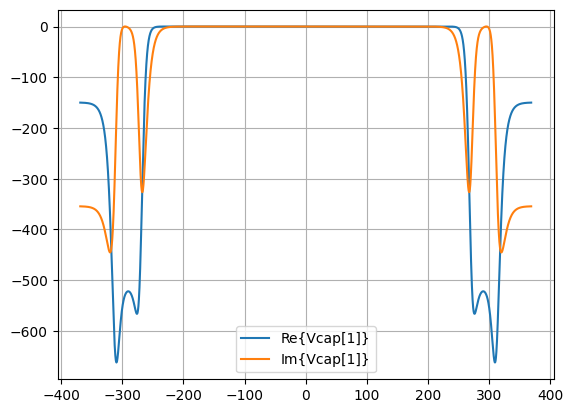

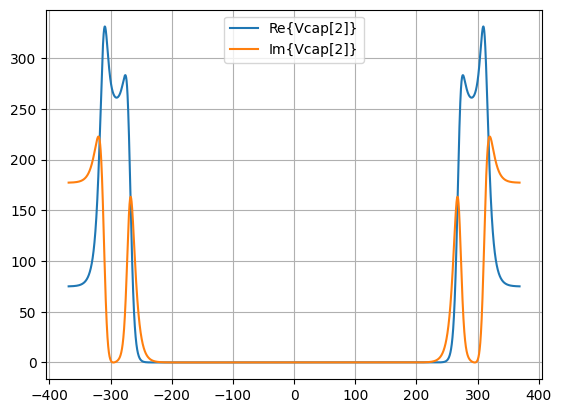

In [20]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

In [21]:
# Időfejlődés observeres megközelítéssel
def collect_time_evolution(psi0_grid, psi1_grid, psi_grid, uxgrid, t, i, utgrid, psi_arr, psi1_arr):
    psi_arr[:, i] = psi_grid
    psi1_arr[:, i] = psi1_grid

# Előre allokált tömbök létrehozása
num_x = len(uxgrid)
num_t = len(utgrid)
psi_pk_te_arr = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_pk_te_arr = np.zeros((num_x, num_t), dtype=np.complex128)
psi_mk_te_arr = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_mk_te_arr = np.zeros((num_x, num_t), dtype=np.complex128)


psi_pk_te=quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap
)
psi_mk_te=quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap
)

# Futtatás observerrel, eredmények gyűjtése a tömbökbe
psi_pk_te.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr, psi1_pk_te_arr
))
psi_mk_te.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr, psi1_mk_te_arr
))

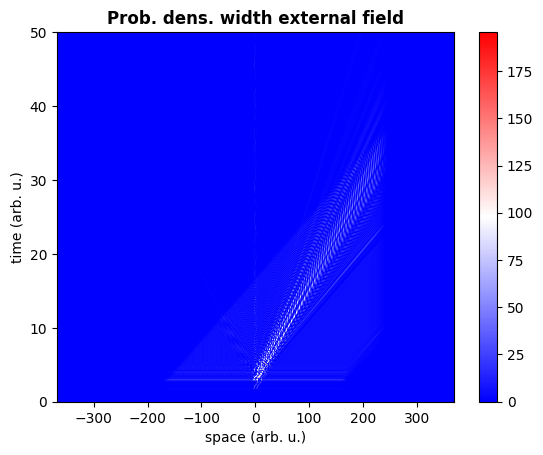

: 

In [ ]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(uxgrid, utgrid)
Z = np.abs(psi1_pk_te_arr)**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,50])
plt.show()

In [ ]:
X,Y = np.meshgrid(uxgrid,utgrid[:])

psi_pk_te_wf = quat.Wavefunction(grid=uxgrid, value=psi_pk_te_arr)

Z=np.transpose(quat.probability_density(psi_pk_te_wf))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution["value"]))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-30, 30])
plt.ylim([0,15])
plt.show()

# Compute probability current

In [ ]:
# choose masurement points on the right and the left side
meas_point_right=205
meas_point_left=-meas_point_right

In [ ]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

3636 12747
-205.01001281816517 205.01001281816514


In [ ]:
psi1 = psi_pk_te.psi1_time_evolution
print(type(psi1))

<class 'quantum_toolkit.quantum_toolkit.Wavefunction'>


In [ ]:
psi0 = psi_pk_te.psi0_time_evolution
print(type(psi0))

<class 'quantum_toolkit.quantum_toolkit.Wavefunction'>


In [ ]:
psi=psi_pk_te.psi_time_evolution
print(type(psi))

<class 'quantum_toolkit.quantum_toolkit.Wavefunction'>


In [ ]:
pc_pk_psi=quat.probability_current(quat.Wavefunction(grid=psi0.grid,value=psi0.value + psi1.value))

In [ ]:
pc_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc_mk=quat.probability_current(psi_mk_te.psi_time_evolution)


In [ ]:
pc_sum=pc_pk+pc_mk

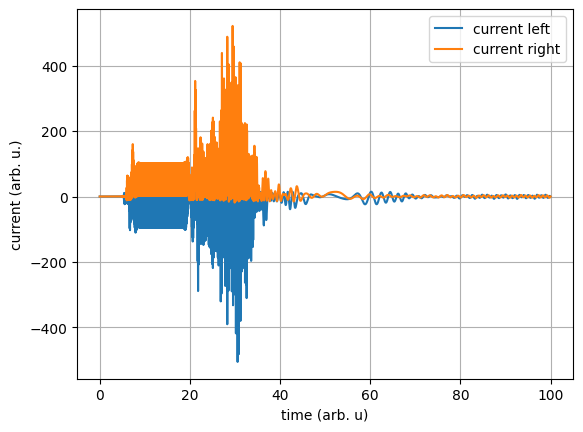

In [ ]:
pc_sum_left=pc_sum[left_index,:]
pc_sum_right=pc_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid[:-1], pc_sum_left,label="current left")
plt.plot(utgrid[:-1], pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

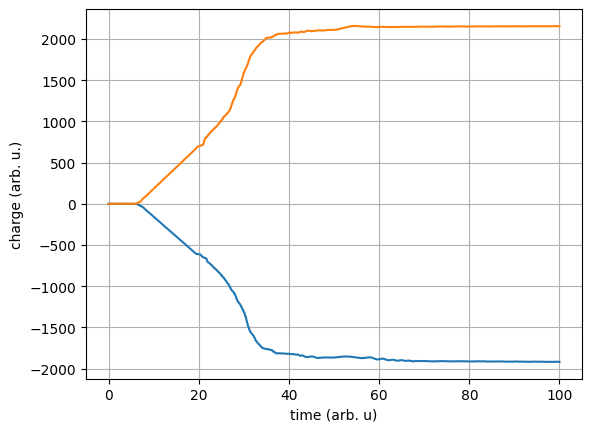

In [ ]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid[:-1], initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid[:-1], initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid[:-1], charge_left,label="charge left")
plt.plot(utgrid[:-1], charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [ ]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

NameError: name 'masked_psi_pk_te' is not defined

In [ ]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-105.19999999997736 104.80000000007038


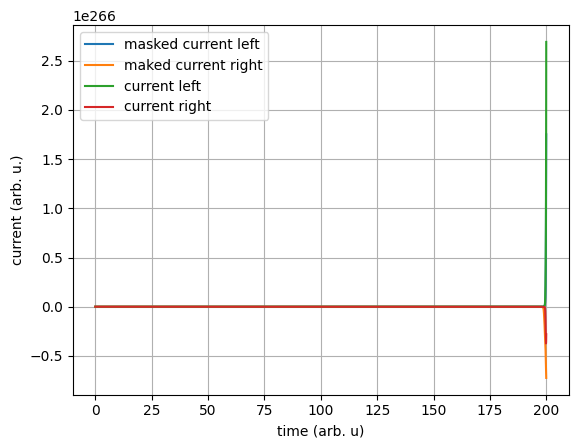

In [ ]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

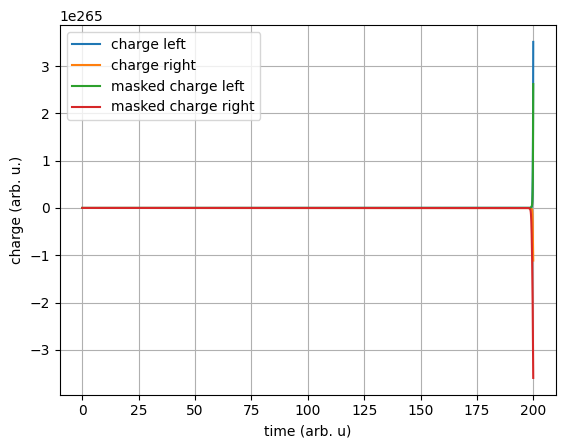

In [ ]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from itertools import product
import io

# Paraméterek definiálása
param_ranges = {
    "electron_energy": np.linspace(1, 5, 5),  # Elektron energiák (eV)
    "pulse_width": np.linspace(50, 200, 4),  # Lézer impulzus szélességek (fs)
    "pulse_frequency": np.linspace(0.5, 2.0, 4)  # Lézer frekvenciák (PHz)
}

# HDF5 fájl létrehozása az eredmények tárolására
output_file = "simulation_results.h5"
with h5py.File(output_file, "w") as hdf:
    # Paraméterkombinációk iterálása
    for electron_energy, pulse_width, pulse_frequency in product(
        param_ranges["electron_energy"],
        param_ranges["pulse_width"],
        param_ranges["pulse_frequency"]
    ):
        # Szimuláció futtatása (helyettesítsd a saját szimulációs kódoddal)
        time = np.linspace(0, 100, 1000)  # Időtengely (fs)
        signal = np.sin(2 * np.pi * pulse_frequency * time) * np.exp(-time / pulse_width)

        # Eredmények mentése HDF5-be
        group_name = f"energy_{electron_energy}_width_{pulse_width}_freq_{pulse_frequency}"
        group = hdf.create_group(group_name)
        group.create_dataset("time", data=time)
        group.create_dataset("signal", data=signal)

        # Ábra mentése HDF5-be
        fig, ax = plt.subplots()
        ax.plot(time, signal, label=f"E={electron_energy} eV, W={pulse_width} fs, F={pulse_frequency} PHz")
        ax.set_xlabel("Time (fs)")
        ax.set_ylabel("Signal")
        ax.set_title("Simulation Result")
        ax.legend()
        ax.grid()

        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        group.create_dataset("plot", data=np.frombuffer(buf.getvalue(), dtype='uint8'))
        plt.close(fig)

print(f"Simulation results saved to {output_file}")

Simulation results saved to simulation_results.h5
